# Information-Driven Bars: López de Prado

*Based on López de Prado, M. (2018). Advances in Financial Machine Learning. Wiley. Chapter 2.*

Traditional **time bars** sample at fixed intervals (e.g. 1 minute). This underprovides information in high-activity periods and overprovides in low-activity periods. Mandelbrot and Taylor (1967) showed that **price changes over a fixed number of transactions are Gaussian**, while over fixed time they are Paretian (infinite variance). Sampling by *information arrival* yields returns closer to IID.

## Bar Types

| Bar Type | Sampling Rule | Use Case |
|----------|---------------|----------|
| **Time bars** | Fixed time interval | Baseline, familiar |
| **Tick bars** | Fixed number of transactions | Normalize by activity |
| **Volume bars** | Fixed traded volume | Normalize by size |
| **Dollar bars** | Fixed dollar value (Price × Qty) | Information flow | 

Mandelbrot and Taylor (1967): price changes over a fixed number of transactions are Gaussian; over fixed time they are Paretian (infinite variance). Sampling by transactions yields returns closer to Normal IID. 

In [4]:
import sys
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Project root (find directory containing pyproject.toml)
ROOT = Path.cwd().resolve()
for _ in range(5):
    if (ROOT / "pyproject.toml").exists():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INPUTS = ROOT / "inputs"
OUTPUTS = ROOT / "outputs"

In [5]:
# Load tick data (cleaned: drops invalid rows)
df = pd.read_csv(INPUTS / "btc_bid_ask_data.csv")
df = df.dropna(subset=["time", "Price", "Quantity"])
df = df[(df["time"] >= 1e9) & (df["Price"] > 0) & (df["Quantity"] > 0)]
df = df.sort_values("time").reset_index(drop=True)
print(f"Loaded {len(df):,} ticks")

Loaded 31,531 ticks


In [6]:
# Generate bars using López de Prado formulations
from financial_machine_learning.bars import dollar_bars, tick_bars, time_bars, volume_bars

# Time bars (1-second)
time_bars_df = time_bars(df)
time_bars_df = time_bars_df[time_bars_df["datetime"].dt.year > 2000]  # drop bad rows

# Tick bars (100 ticks per bar)
tick_b = tick_bars(df, threshold=100)

# Volume bars (~300 bars total)
vol_threshold = df["Quantity"].sum() / 300
vol_b = volume_bars(df, threshold=vol_threshold)

# Dollar bars (information bars, ~300 bars)
dollar_threshold = (df["Price"] * df["Quantity"]).sum() / 300
dollar_b = dollar_bars(df, threshold=dollar_threshold)

print(f"Time bars: {len(time_bars_df):,} | Tick: {len(tick_b):,} | Volume: {len(vol_b):,} | Dollar: {len(dollar_b):,}")

Time bars: 10,968 | Tick: 316 | Volume: 297 | Dollar: 298


## Save cleaned bar data

In [7]:
OUTPUTS.mkdir(parents=True, exist_ok=True)
time_bars_df.to_csv(OUTPUTS / "btc_bid_ask_data_1s.csv", index=False)
tick_b.to_csv(OUTPUTS / "btc_bid_ask_data_tick_bars.csv", index=False)
vol_b.to_csv(OUTPUTS / "btc_bid_ask_data_volume_bars.csv", index=False)
dollar_b.to_csv(OUTPUTS / "btc_bid_ask_data_dollar_bars.csv", index=False)
print("Saved all bar types to outputs/")

Saved all bar types to outputs/


## Price series comparison

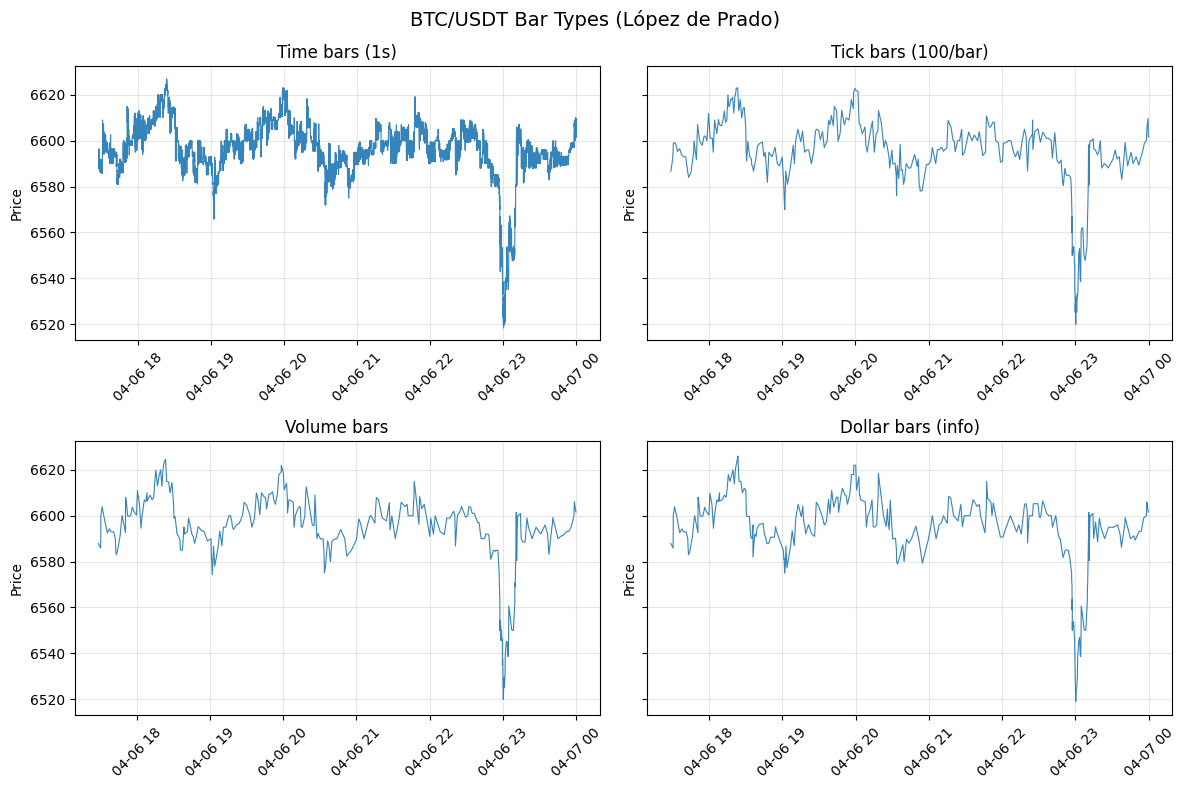

In [ ]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=("Time bars (1s)", "Tick bars (100/bar)", "Volume bars", "Dollar bars (info)"),
    shared_yaxes=True,
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)
for i, (name, bars) in enumerate([
    ("Time bars (1s)", time_bars_df),
    ("Tick bars (100/bar)", tick_b),
    ("Volume bars", vol_b),
    ("Dollar bars (info)", dollar_b),
]):
    t = pd.to_datetime(bars["datetime"]) if bars["datetime"].dtype != "datetime64[ns]" else bars["datetime"]
    r, c = i // 2 + 1, i % 2 + 1
    fig.add_trace(go.Scatter(x=t, y=bars["close"], name=name, mode="lines", line={"width": 1}), row=r, col=c)
fig.update_layout(height=500, title_text="BTC/USDT Bar Types (López de Prado)", showlegend=False)
fig.update_xaxes(tickangle=-45)
fig.show()

## Returns distribution (IID test)

Tick and volume bars should produce returns closer to Gaussian than time bars.

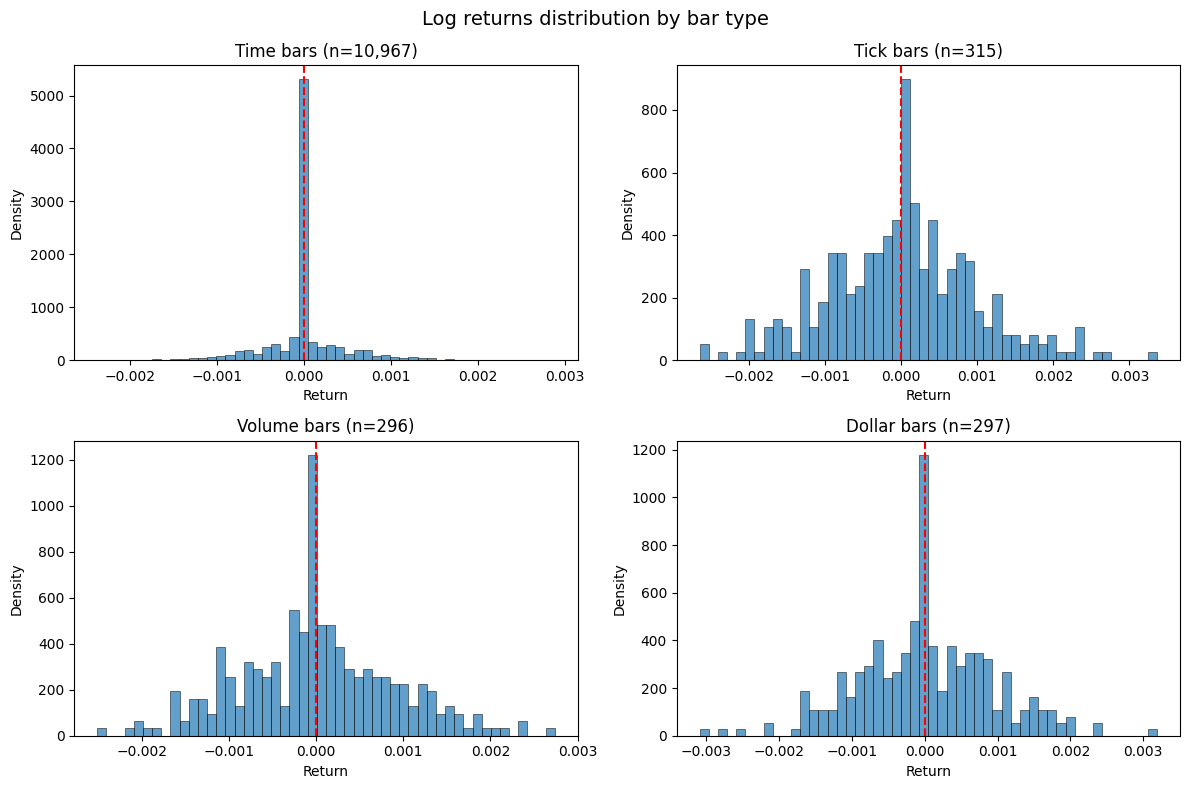

In [ ]:
def returns(bars: pd.DataFrame) -> pd.Series:
    return bars["close"].pct_change().dropna()


fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        f"{n} (n={len(returns(b)):,})"
        for n, b in [
            ("Time bars", time_bars_df),
            ("Tick bars", tick_b),
            ("Volume bars", vol_b),
            ("Dollar bars", dollar_b),
        ]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)
for i, (name, bars) in enumerate([
    ("Time bars", time_bars_df),
    ("Tick bars", tick_b),
    ("Volume bars", vol_b),
    ("Dollar bars", dollar_b),
]):
    ret = returns(bars)
    r, c = i // 2 + 1, i % 2 + 1
    fig.add_trace(
        go.Histogram(x=ret, nbinsx=50, histnorm="probability density", name=name, showlegend=False), row=r, col=c
    )
    fig.add_vline(x=0, line_dash="dash", line_color="red", row=r, col=c)
fig.update_layout(height=500, title_text="Log returns distribution by bar type")
fig.update_xaxes(title_text="Return")
fig.update_yaxes(title_text="Density")
fig.show()